In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.fetch_data import fetch_macro_basket, fetch_sp500_universe, compute_returns, save_dataset, MACRO_TICKERS, START_DATE, END_DATE
from src.rolling_correlation import compute_rolling_correlation, compute_correlation_matrix, compute_rolling_correlation_matrix_series
from src.visualize import build_pair_correlation_dashboard, plot_rolling_correlation_pair

import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
macro_prices = fetch_macro_basket()
macro_returns = compute_returns(macro_prices)
save_dataset(macro_prices, macro_returns, prefix="macro")

macro_returns.tail()

2026-08-22 11:39:35,574 [INFO] Fetching macro basket: 19 assets...
2026-08-22 11:39:35,575 [INFO] Downloading chunk 1/1 (19 tickers)...
2026-08-22 11:39:40,185 [INFO] Saved macro prices/returns to /Users/paulgrajzl/Documents/Quant-Projects/correlation-regime-shift/data/


Ticker,BTC-USD,EEM,EFA,GLD,HYG,IEF,IWM,LQD,QQQ,RSP,SHY,SLV,SPY,TLT,USO,UUP,^IRX,^TNX,^VIX
Date,,,,,,,,,,,,,,,,,,,
2026-07-21,0.019548,0.028005,0.014527,0.019614,-0.000376,-0.002459,0.014471,-0.002800,0.018547,0.001601,-0.000854,0.041193,0.008341,-0.002742,0.026611,0.003170,0.006748,0.006525,-0.085791
2026-07-22,-0.006080,-0.005357,0.001826,0.011499,-0.001632,-0.002251,-0.009274,-0.001685,-0.005106,-0.000282,-0.000733,0.015825,-0.001163,-0.002630,0.021963,-0.001053,0.004021,0.006266,-0.024047
2026-07-23,-0.015975,-0.006001,-0.012950,-0.020046,-0.003647,-0.002685,-0.005786,-0.003844,-0.018983,-0.003667,-0.000733,-0.034495,-0.012349,-0.003236,0.059311,0.003866,0.014686,0.009878,0.123798
2026-07-24,-0.014549,-0.019659,0.004956,0.001023,0.000000,0.001939,-0.003150,-0.000282,-0.011171,0.007786,0.000978,0.010181,0.001016,0.000962,-0.020073,0.000700,0.001316,-0.005103,-0.006417
2026-07-27,-0.005828,0.004579,0.004835,0.007341,0.000505,0.002687,0.005976,0.002636,-0.003084,0.007538,0.000244,0.006465,0.000217,0.006006,-0.087278,0.000700,-0.002103,-0.008121,0.004844


In [4]:
# Use this instead of Cell 2 once you've already fetched today's data,
# so you're not re-hitting yfinance every session.
DATA_DIR = Path().resolve().parent / "data"

macro_prices = pd.read_csv(DATA_DIR / "macro_prices.csv", index_col=0, parse_dates=True)
macro_returns = pd.read_csv(DATA_DIR / "macro_returns.csv", index_col=0, parse_dates=True)

macro_returns.tail()

,BTC-USD,EEM,EFA,GLD,HYG,IEF,IWM,LQD,QQQ,RSP,SHY,SLV,SPY,TLT,USO,UUP,^IRX,^TNX,^VIX
Date,,,,,,,,,,,,,,,,,,,
2026-07-21,0.019548,0.028005,0.014527,0.019614,-0.000376,-0.002459,0.014471,-0.002800,0.018547,0.001601,-0.000854,0.041193,0.008341,-0.002742,0.026611,0.003170,0.006748,0.006525,-0.085791
2026-07-22,-0.006080,-0.005357,0.001826,0.011499,-0.001632,-0.002251,-0.009274,-0.001685,-0.005106,-0.000282,-0.000733,0.015825,-0.001163,-0.002630,0.021963,-0.001053,0.004021,0.006266,-0.024047
2026-07-23,-0.015975,-0.006001,-0.012950,-0.020046,-0.003647,-0.002685,-0.005786,-0.003844,-0.018983,-0.003667,-0.000733,-0.034495,-0.012349,-0.003236,0.059311,0.003866,0.014686,0.009878,0.123798
2026-07-24,-0.014549,-0.019659,0.004956,0.001023,0.000000,0.001939,-0.003150,-0.000282,-0.011171,0.007786,0.000978,0.010181,0.001016,0.000962,-0.020073,0.000700,0.001316,-0.005103,-0.006417
2026-07-27,-0.005828,0.004579,0.004835,0.007341,0.000505,0.002687,0.005976,0.002636,-0.003084,0.007538,0.000244,0.006465,0.000217,0.006006,-0.087278,0.000700,-0.002103,-0.008121,0.004844


In [5]:
spy_tlt_corr = compute_rolling_correlation(macro_returns, "SPY", "TLT", window=60)
spy_tlt_corr.tail()

Date
2026-07-21    0.388948
2026-07-22    0.387098
2026-07-23    0.395222
2026-07-24    0.399782
2026-07-27    0.398078
dtype: float64

Saved rolling correlation plot to /Users/paulgrajzl/Documents/Quant-Projects/correlation-regime-shift/output/rolling_corr_SPY_vs_TLT.png


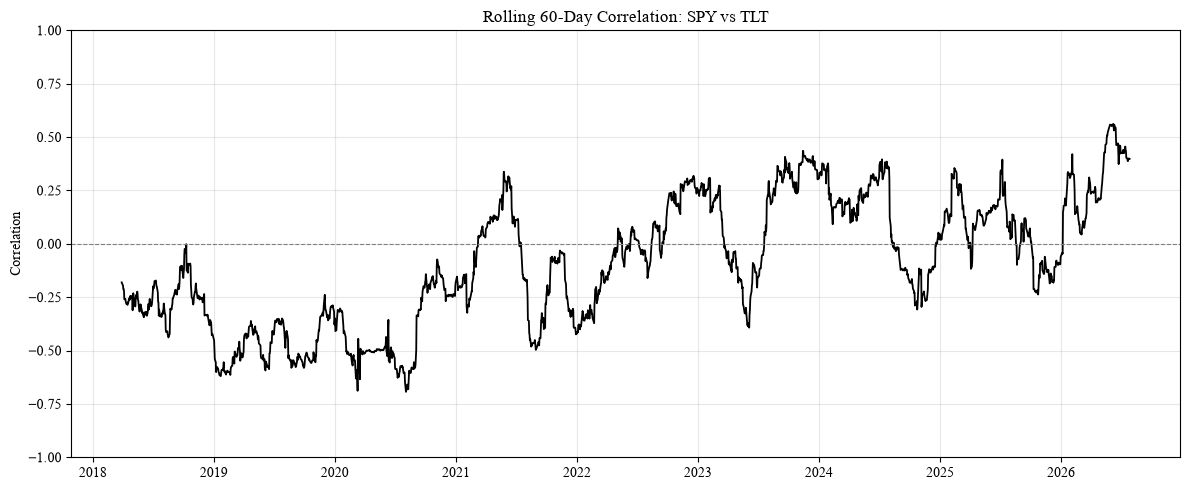

In [6]:
plot_rolling_correlation_pair(
    macro_returns,
    ticker_a="SPY",
    ticker_b="TLT",
    window=60,
    pair_label="SPY vs TLT",
)

In [ ]:
build_pair_correlation_dashboard(macro_returns, ticker_labels=MACRO_TICKERS, window=60)

Output()